In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and set up dataset
df = pd.read_csv('../data/store1_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Train/test split - last 90 days = test
train = df['Sales'][:-90]
test = df['Sales'][-90:]

# Print verification stats
print("Train size:", len(train))
print("Test size:", len(test))
print("Train period:", train.index[0].date(), "to", train.index[-1].date())
print("Test period:", test.index[0].date(), "to", test.index[-1].date())

Train size: 851
Test size: 90
Train period: 2013-01-02 to 2015-05-02
Test period: 2015-05-03 to 2015-07-31


Naive RMSE: 2837.93
Moving_Average_30d RMSE: 1836.92


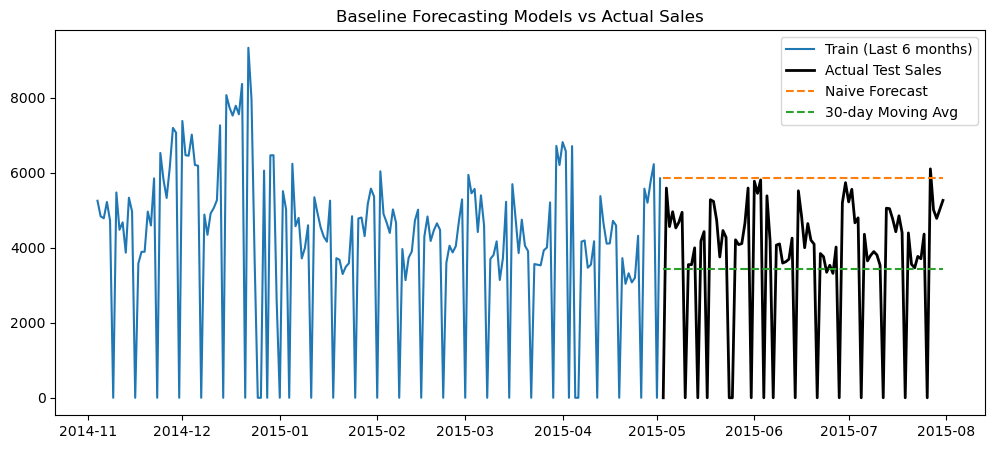

In [11]:
# Create a dataframe to store our test predictions
predictions = pd.DataFrame(index=test.index)
predictions['Actual'] = test

# 1. Naive Forecast (Carries the last value of train forward)
predictions['Naive'] = train.iloc[-1]

# 2. Moving Average Forecast (Takes the average of the last 30 days of train)
predictions['Moving_Average_30d'] = train.tail(30).mean()

# Calculate Evaluation Metrics (Root Mean Squared Error)
from sklearn.metrics import mean_squared_error

for model in ['Naive', 'Moving_Average_30d']:
    rmse = np.sqrt(mean_squared_error(predictions['Actual'], predictions[model]))
    print(f"{model} RMSE: {rmse:.2f}")

# Plot the comparison
plt.figure(figsize=(12, 5))
plt.plot(train[-180:], label='Train (Last 6 months)')
plt.plot(predictions['Actual'], label='Actual Test Sales', color='black', lw=2)
plt.plot(predictions['Naive'], label='Naive Forecast', linestyle='--')
plt.plot(predictions['Moving_Average_30d'], label='30-day Moving Avg', linestyle='--')
plt.title('Baseline Forecasting Models vs Actual Sales')
plt.legend()
plt.show()

In [19]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Feature engineering
def create_features(df):
    df = df.copy()
    df['DayOfWeek'] = df.index.dayofweek
    df['Month'] = df.index.month
    df['DayOfMonth'] = df.index.day
    df['Sales_Lag_7'] = df['Sales'].shift(7)
    df['Sales_Lag_14'] = df['Sales'].shift(14)
    return df.dropna()

df_feat = create_features(df)

X = df_feat[['DayOfWeek', 'Month', 'DayOfMonth', 'Sales_Lag_7', 'Sales_Lag_14']]
y = df_feat['Sales']

X_train = X.iloc[:-90]
X_test  = X.iloc[-90:]
y_train = y.iloc[:-90]
y_test  = y.iloc[-90:]

# Train XGBoost
model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost MAE:  {mae:.2f}")
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/best_xgb_model.pkl')
print("Model saved to models/best_xgb_model.pkl")

XGBoost RMSE: 952.35
XGBoost MAE:  520.37
Model saved to models/best_xgb_model.pkl


Random Forest RMSE: 903.15


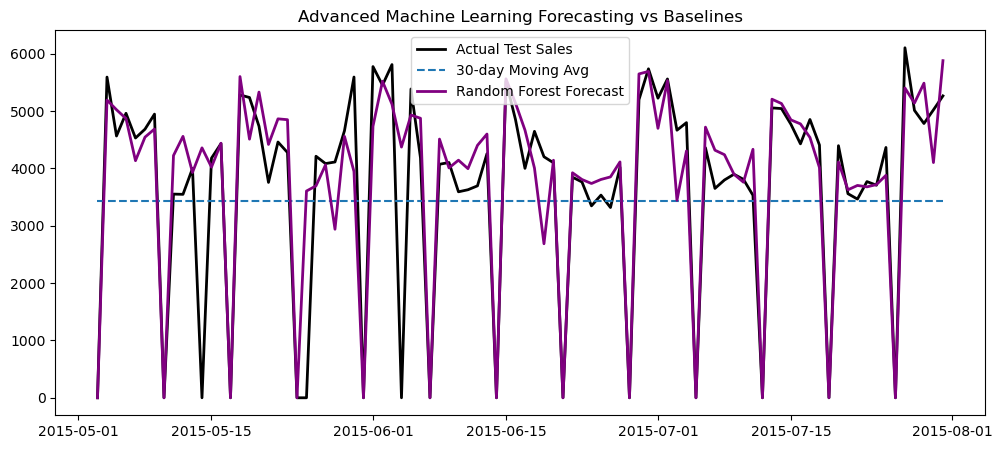

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Re-load a fresh copy of the clean data to build features safely
df_ml = pd.read_csv('../data/store1_clean.csv')
df_ml['Date'] = pd.to_datetime(df_ml['Date'])
df_ml = df_ml.set_index('Date')

# 1. Feature Engineering: Extract calendar rhythms
df_ml['DayOfWeek'] = df_ml.index.dayofweek
df_ml['Month'] = df_ml.index.month
df_ml['DayOfMonth'] = df_ml.index.day

# 2. Lag Features: Give the model a memory of recent sales
df_ml['Sales_Lag_7'] = df_ml['Sales'].shift(7)
df_ml['Sales_Lag_14'] = df_ml['Sales'].shift(14)

# Drop rows with NaN values caused by shifting lags
df_ml = df_ml.dropna()

# 3. Separate Features (X) and Target (y)
X = df_ml[['DayOfWeek', 'Month', 'DayOfMonth', 'Sales_Lag_7', 'Sales_Lag_14']]
y = df_ml['Sales']

# 4. Train/Test Split (Keep matching the last 90 days for testing)
X_train, X_test = X[:-90], X[-90:]
y_train, y_test = y[:-90], y[-90:]

# 5. Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Predict and Evaluate
predictions['Random_Forest'] = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(predictions['Actual'], predictions['Random_Forest']))
print(f"Random Forest RMSE: {rf_rmse:.2f}")

# 7. Plot the updated results
plt.figure(figsize=(12, 5))
plt.plot(predictions['Actual'], label='Actual Test Sales', color='black', lw=2)
plt.plot(predictions['Moving_Average_30d'], label='30-day Moving Avg', linestyle='--')
plt.plot(predictions['Random_Forest'], label='Random Forest Forecast', color='purple', lw=2)
plt.title('Advanced Machine Learning Forecasting vs Baselines')
plt.legend()
plt.show()

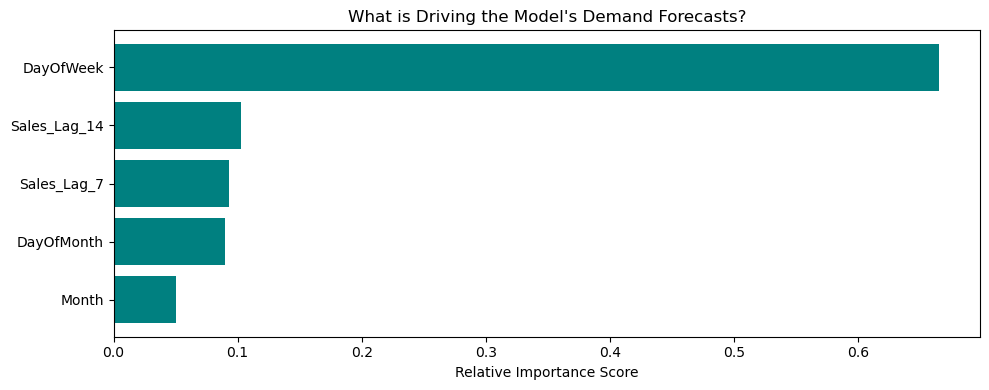

In [14]:
# Extract feature importance values from our trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Organize into a clean DataFrame
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot a horizontal bar chart
plt.figure(figsize=(10, 4))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='teal')
plt.title('What is Driving the Model\'s Demand Forecasts?')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

XGBoost RMSE: 904.83


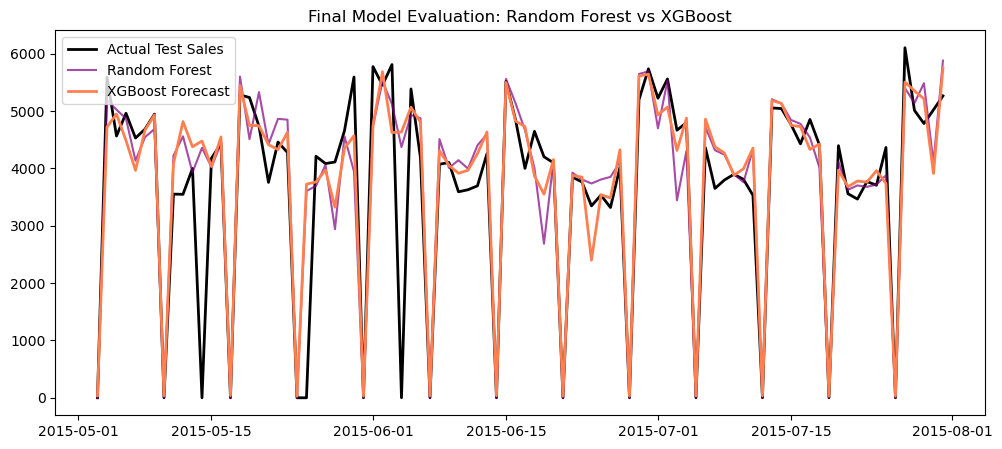

In [15]:
from xgboost import XGBRegressor

# 1. Train XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

# 2. Predict and Evaluate
predictions['XGBoost'] = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(predictions['Actual'], predictions['XGBoost']))
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

# 3. Final Model Comparison Plot
plt.figure(figsize=(12, 5))
plt.plot(predictions['Actual'], label='Actual Test Sales', color='black', lw=2)
plt.plot(predictions['Random_Forest'], label='Random Forest', color='purple', alpha=0.7)
plt.plot(predictions['XGBoost'], label='XGBoost Forecast', color='coral', lw=2)
plt.title('Final Model Evaluation: Random Forest vs XGBoost')
plt.legend()
plt.show()

In [16]:
import joblib
import os

# 1. Create a directory to save models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# 2. Save the best performing XGBoost model
model_path = '../models/best_xgb_model.pkl'
joblib.dump(xgb_model, model_path)

print(f"🎉 Success! Best model saved cleanly to: {model_path}")

🎉 Success! Best model saved cleanly to: ../models/best_xgb_model.pkl


In [17]:
import pandas as pd
import numpy as np

# 1. Simulate incoming new data for next week (7 days)
print("🔮 Generating Forecasts for the Next 7 Days...")
future_dates = pd.date_range(start='2015-08-01', periods=7, freq='D')

# 2. Create the matching feature matrix structure
future_df = pd.DataFrame(index=future_dates)
future_df['DayOfWeek'] = future_df.index.dayofweek
future_df['Month'] = future_df.index.month
future_df['DayOfMonth'] = future_df.index.day

# Mock recent lag values (simulating the last known week of sales)
future_df['Sales_Lag_7'] = [4100, 3800, 3900, 4200, 5100, 6000, 3200]
future_df['Sales_Lag_14'] = [4000, 3750, 3850, 4100, 5000, 5900, 3100]

# 3. Generate predictions directly using the active model in memory
features = future_df[['DayOfWeek', 'Month', 'DayOfMonth', 'Sales_Lag_7', 'Sales_Lag_14']]
future_df['Forecasted_Sales'] = xgb_model.predict(features)

# 4. Display the clean output table
print("\n📋 Final Demand Forecast Results:")
print("-" * 55)
for date, row in future_df.iterrows():
    print(f"Date: {date.date()} | Day: {date.day_name():10} | Predicted Demand: {int(row['Forecasted_Sales'])} units")
print("-" * 55)

🔮 Generating Forecasts for the Next 7 Days...

📋 Final Demand Forecast Results:
-------------------------------------------------------
Date: 2015-08-01 | Day: Saturday   | Predicted Demand: 4688 units
Date: 2015-08-02 | Day: Sunday     | Predicted Demand: 154 units
Date: 2015-08-03 | Day: Monday     | Predicted Demand: 5116 units
Date: 2015-08-04 | Day: Tuesday    | Predicted Demand: 4809 units
Date: 2015-08-05 | Day: Wednesday  | Predicted Demand: 5014 units
Date: 2015-08-06 | Day: Thursday   | Predicted Demand: 4777 units
Date: 2015-08-07 | Day: Friday     | Predicted Demand: 4474 units
-------------------------------------------------------


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 520.3741455078125
RMSE : 952.3497584921204
R2 Score : 0.7266722917556763
